# 06 — Prévision du chiffre d'affaires mensuel

**Question métier :** quel CA attendre sur les 3 prochains mois (mars à mai 2025) ?

**Données :** CA brut mensuel des ventes en USD, de janvier 2023 à février 2025 (**26 mois**, mars 2025 incomplet exclu). C'est très court : à peine plus de **2 cycles saisonniers**, le minimum pour estimer une saisonnalité annuelle.

**Démarche :** comparer un modèle statistique (Holt-Winters) à des **baselines naïves saisonnières** sur les derniers mois connus, puis ne retenir le modèle complexe que s'il fait mieux.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from src.db import get_engine, read_sql
from src.plotting import MUTED, PALETTE, PRIMARY, millions, set_style

set_style()
engine = get_engine()

SEASON = 12
TEST_MONTHS = 2
HORIZON = 3

## 1. Série mensuelle

26 mois : Jan 2023 -> Feb 2025


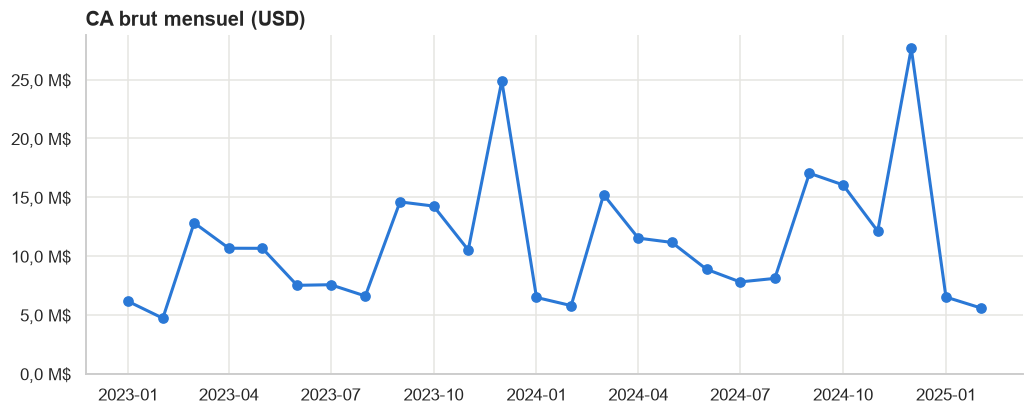

In [2]:
monthly = read_sql("""
    SELECT d.[Year], d.[Month], SUM(f.Line_Total_USD) AS Revenue_USD
    FROM warehouse.vw_Fact_Sales_USD AS f
    JOIN warehouse.Dim_Date AS d ON d.Date_Key = f.Date_Key
    WHERE f.Transaction_Type = 'Sale'
    GROUP BY d.[Year], d.[Month]
""", engine)

revenue = (
    monthly.assign(Period=pd.to_datetime(dict(year=monthly["Year"], month=monthly["Month"], day=1)))
    .set_index("Period")["Revenue_USD"]
    .sort_index()
    .asfreq("MS")
)
revenue = revenue[revenue.index < "2025-03-01"]  # mars 2025 : seulement 18 jours
print(f"{len(revenue)} mois : {revenue.index.min():%b %Y} -> {revenue.index.max():%b %Y}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(revenue.index, revenue.values, marker="o", color=PRIMARY)
ax.yaxis.set_major_formatter(millions())
ax.set_ylim(bottom=0)
ax.set_title("CA brut mensuel (USD)")
plt.show()

## 2. Modèles comparés

| Modèle | Prévision pour le mois *m* |
|---|---|
| Naïf saisonnier | CA du même mois l'année précédente |
| Naïf saisonnier + croissance | idem, multiplié par la croissance des 12 derniers mois vs les 12 précédents |
| Holt-Winters | lissage exponentiel avec tendance et saisonnalité additives |

In [3]:
def future_index(history: pd.Series, horizon: int) -> pd.DatetimeIndex:
    return pd.date_range(history.index[-1] + pd.offsets.MonthBegin(), periods=horizon, freq="MS")


def seasonal_naive(history: pd.Series, horizon: int) -> pd.Series:
    return pd.Series(history.iloc[-SEASON:].iloc[:horizon].to_numpy(), index=future_index(history, horizon))


def seasonal_naive_growth(history: pd.Series, horizon: int) -> pd.Series:
    growth = history.iloc[-SEASON:].sum() / history.iloc[-2 * SEASON:-SEASON].sum()
    return seasonal_naive(history, horizon) * growth


def holt_winters(history: pd.Series, horizon: int) -> pd.Series:
    model = ExponentialSmoothing(
        history, trend="add", seasonal="add", seasonal_periods=SEASON,
        initialization_method="estimated",
    ).fit()
    return model.forecast(horizon)


FORECASTERS = {
    "Naïf saisonnier": seasonal_naive,
    "Naïf saisonnier + croissance": seasonal_naive_growth,
    "Holt-Winters": holt_winters,
}

## 3. Validation sur les 2 derniers mois connus (janvier-février 2025)

Holt-Winters a besoin de 24 mois d'entraînement : il ne reste que 2 mois pour tester. Les scores sont donc **indicatifs** (2 points de mesure seulement).

In [4]:
train, test = revenue.iloc[:-TEST_MONTHS], revenue.iloc[-TEST_MONTHS:]
backtest = {name: forecaster(train, TEST_MONTHS) for name, forecaster in FORECASTERS.items()}

scores = pd.DataFrame({
    name: {
        "MAPE": (forecast / test - 1).abs().mean(),
        "Erreur absolue moyenne (USD)": (forecast - test).abs().mean(),
    }
    for name, forecast in backtest.items()
}).T.sort_values("MAPE")

scores.style.format({"MAPE": "{:.1%}", "Erreur absolue moyenne (USD)": "{:,.0f}"})

,MAPE,Erreur absolue moyenne (USD)
Naïf saisonnier,2.0%,"113,741"
Naïf saisonnier + croissance,14.6%,"871,841"
Holt-Winters,38.9%,"2,333,756"


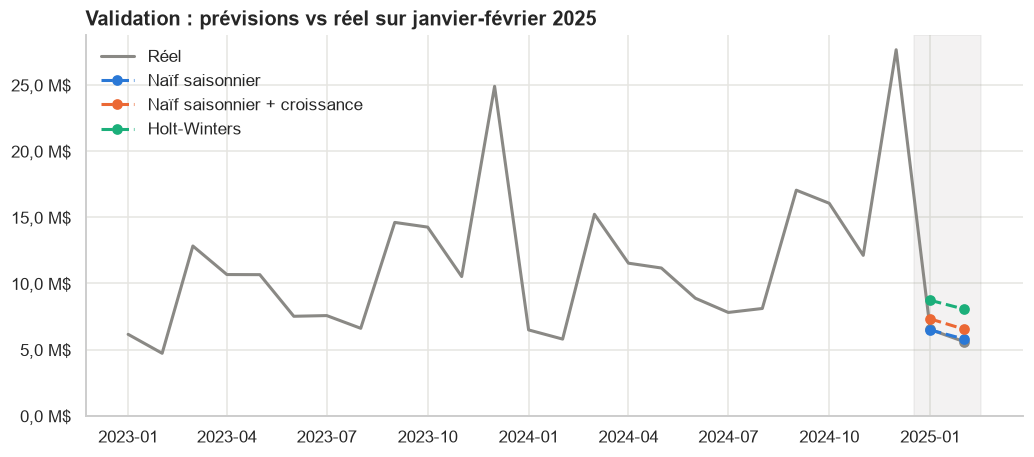

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(revenue.index, revenue.values, color=MUTED, label="Réel")
ax.plot(test.index, test.values, "o", color=MUTED)
for color, (name, forecast) in zip(PALETTE, backtest.items()):
    ax.plot(forecast.index, forecast.values, "o--", color=color, label=name)
ax.axvspan(test.index[0] - pd.Timedelta(days=15), test.index[-1] + pd.Timedelta(days=15),
           color=MUTED, alpha=0.1)
ax.yaxis.set_major_formatter(millions())
ax.set_ylim(bottom=0)
ax.set_title("Validation : prévisions vs réel sur janvier-février 2025")
ax.legend(frameon=False, loc="upper left")
plt.show()

**Résultat : la baseline la plus simple gagne largement.**
- **Naïf saisonnier : MAPE de 2,0 %.** Le CA de janvier-février 2025 est presque identique à celui de janvier-février 2024.
- **Naïf saisonnier + croissance : 14,6 %.** La croissance de 2024 (+13 %) ne s'est pas prolongée au début de 2025 ; l'appliquer surestime le CA.
- **Holt-Winters : 38,9 %.** Avec seulement 2 cycles d'entraînement, le modèle extrapole une tendance trop forte et surestime nettement janvier-février. C'était le seul modèle de la première version du projet.

La leçon est classique en prévision : **toujours se comparer à une baseline naïve**. Un modèle plus sophistiqué n'est pas forcément meilleur, surtout avec un historique court et une saisonnalité très stable.

## 4. Prévision mars-mai 2025 avec le meilleur modèle

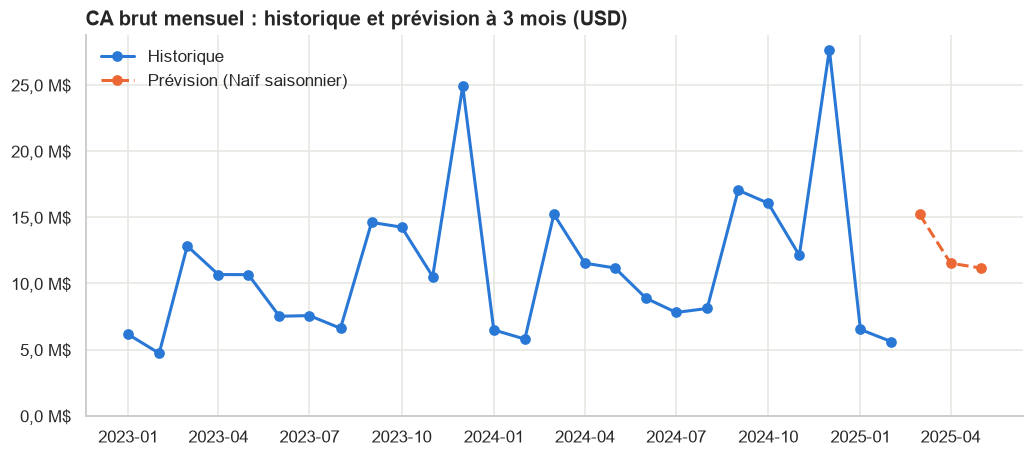

,Prévision (USD)
2025-03-01 00:00:00,"15,222,631"
2025-04-01 00:00:00,"11,527,458"
2025-05-01 00:00:00,"11,162,130"


In [6]:
best_name = scores.index[0]
forecast = FORECASTERS[best_name](revenue, HORIZON)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(revenue.index, revenue.values, marker="o", color=PRIMARY, label="Historique")
ax.plot(forecast.index, forecast.values, "o--", color=PALETTE[1], label=f"Prévision ({best_name})")
ax.yaxis.set_major_formatter(millions())
ax.set_ylim(bottom=0)
ax.set_title("CA brut mensuel : historique et prévision à 3 mois (USD)")
ax.legend(frameon=False, loc="upper left")
plt.show()

forecast.rename("Prévision (USD)").to_frame().style.format("{:,.0f}")

La prévision reproduit le profil de 2024 : environ **15,2 M$ en mars** (pic de début de collection), puis **11,5 M$ en avril et 11,2 M$ en mai**, soit ~38 M$ sur le trimestre. Elle suppose une activité stable d'une année sur l'autre, en ligne avec ce qui a été observé en janvier-février 2025.

## 5. Export vers SQL Server (Power BI)

In [7]:
forecast_export = pd.DataFrame({
    "Period": forecast.index,
    "Forecast_Revenue_USD": forecast.to_numpy(),
    "Model": best_name,
    "Backtest_MAPE_Pct": round(100 * scores.loc[best_name, "MAPE"], 1),
})
forecast_export.to_sql("Revenue_Forecast", engine, schema="warehouse", if_exists="replace", index=False)
forecast_export

,Period,Forecast_Revenue_USD,Model,Backtest_MAPE_Pct
0,2025-03-01,1.522263e+07,Naïf saisonnier,2.0
1,2025-04-01,1.152746e+07,Naïf saisonnier,2.0
2,2025-05-01,1.116213e+07,Naïf saisonnier,2.0


## Limites

- **Historique très court** (26 mois) : validation sur 2 points seulement, aucune estimation fiable de l'incertitude. La prévision est un **ordre de grandeur**, à afficher avec son erreur de validation (c'est le cas dans le dashboard).
- **Mars 2025 partiellement observé** : les 18 premiers jours pourraient servir à ajuster la prévision de mars (non fait ici pour rester simple).
- **Pas de variables explicatives** : le calendrier promotionnel (`Dim_Discount`) pourrait améliorer la prévision des mois de soldes.
- Avec 3-4 ans d'historique, une validation glissante (*rolling origin*) sur 12 mois et des modèles type SARIMA ou Prophet deviendraient pertinents.